<a href="https://colab.research.google.com/github/ritterb64/taller-calidad-datos/blob/main/taller3_calidad_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TALLER #3
##Profesora: Adriana Collaguazo
##Integrantes:

*   Ritter Briones
*   Mariana Mora
*   Anthony Polo






**Paso 1: Preparación del entorno de trabajo**

In [18]:
#instalacion de librearia pandera
!pip install pandera ydata-profiling missingno -q

#importar librerias
import pandas as pd
import numpy as np
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import(
    MinMaxScaler
    ,RobustScaler
    ,MaxAbsScaler
    ,StandardScaler
    ,PowerTransformer
    ,Normalizer)
import pandera.pandas as pa
from pandera import  Column,Check,DataFrameSchema

In [2]:
#lectura de dataset
df=pd.read_csv("/content/dirty_cafe_sales.csv")

**Paso 2: Exploración inicial y perfilado de datos**

In [3]:
#inspeccion de tipo de datos
df.info()
#el data frame cuenta con con 10000 registros
#se observa que Location y Payment Method son las columna con mayor cantidad de datos faltantes
#y que todos los campos lo estan tomando como object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [4]:
#estadistica descriptiva
df.describe(include="all")

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


<Axes: >

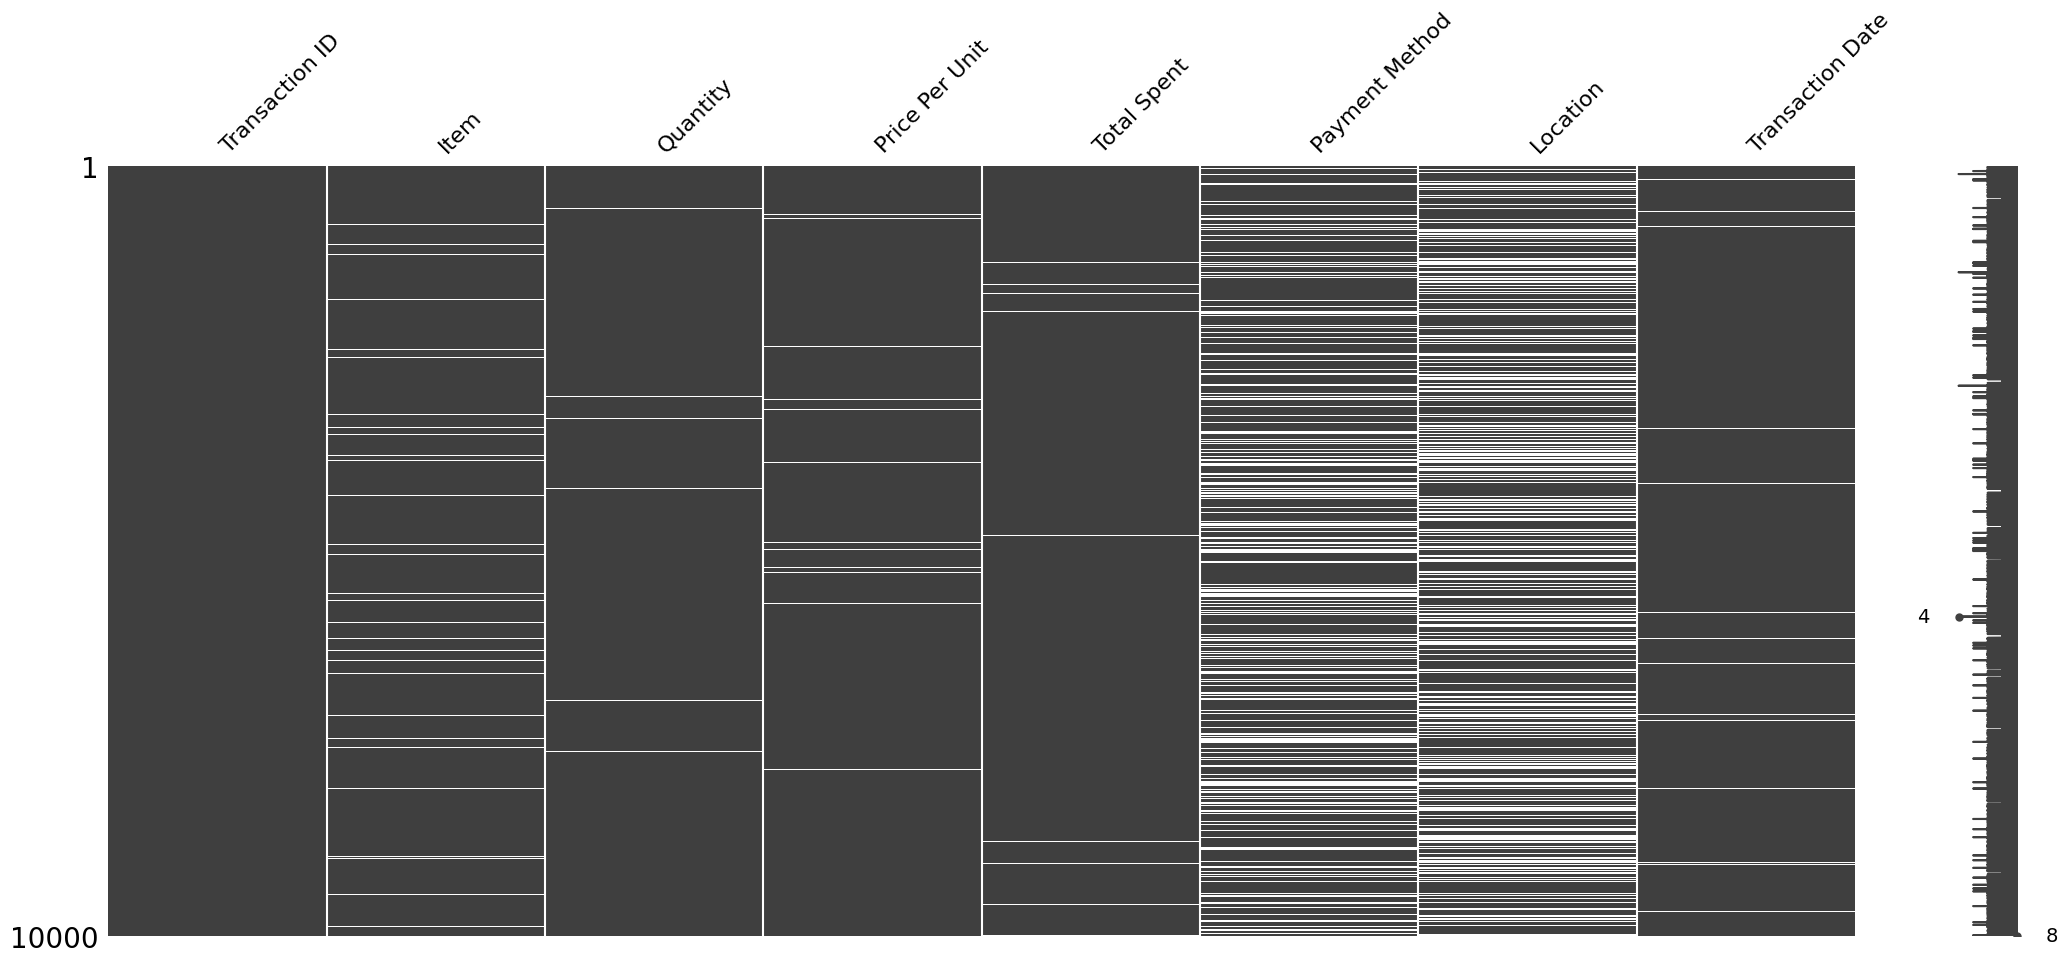

In [5]:
#Patron de valores
msno.matrix(df)
# se demuestra graficamente que Location y Payment Method son las columna con
# mayor cantidad de datos faltantes

In [6]:
#generacion de reporte de calidad de datos
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Reporte de calidad — Tech Coffee Shop", minimal=True)
profile.to_notebook_iframe()

/tmp/ipykernel_3438/3510147607.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 33.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Paso 3: Tratamiento de datos faltantes**

In [7]:
#conteo de valores nulos por columnas
missing_values_count=df.isnull().sum()
missing_values_count

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [8]:
#Porcentaje de valores nulos por columna
(missing_values_count / len(df) * 100).round(2)

,0
Transaction ID,0.00
Item,3.33
Quantity,1.38
Price Per Unit,1.79
Total Spent,1.73
Payment Method,25.79
Location,32.65
Transaction Date,1.59


**Estrategia 1: Eliminar filas con valores nulos**

In [9]:
#Eliminación de filas con al menos un valor nulo

df_sin_filas_nulas = df.dropna()
print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar nulos: {len(df_sin_filas_nulas)}")
print(f"Filas perdidas: {(1 - len(df_sin_filas_nulas) / len(df)):.1%}")

#al evidenciar que el porcentaje de eliminiacion es mas del 5% de los datos
#no es adecuado eliminiar todas las filas nulas

Filas originales: 10000
Filas después de eliminar nulos: 4550
Filas perdidas: 54.5%


**Estrategia 2: Eliminar columnas con valores nulos**

In [11]:
#Eliminación de columnas con al menos un valor nulo

df_sin_columnas_nulas = df.dropna(axis=1)
columnas_originales = df.shape[1]
columnas_restantes = df_sin_columnas_nulas.shape[1]
print(f"Columnas originales: {columnas_originales}")
print(f"Columnas restantes: {columnas_restantes}")
print(f"Columnas eliminadas: {columnas_originales - columnas_restantes}")

#al ser la columna Transaction ID la unica que no tiene valores nulos se esta
#eliminado todo el resto de columna lo cual lo cual no es una buena opcion

Columnas originales: 8
Columnas restantes: 1
Columnas eliminadas: 7


**Estrategia 3: Imputar los datos**

In [12]:
#Valores únicos de la columna Total Spent
df["Total Spent"].unique()

#se evidencia que existen valores cadena como 'ERROR' y 'UNKNOWN' lo cual indica
#que el tipo de dato de la columna es cadena cuando deberia ser numerico

array(['4.0', '12.0', 'ERROR', '10.0', '20.0', '9.0', '16.0', '15.0',
       '25.0', '8.0', '5.0', '3.0', '6.0', nan, 'UNKNOWN', '2.0', '1.0',
       '7.5', '4.5', '1.5'], dtype=object)

In [13]:
#Conversion de cadena a numero de la columna Total Spent
df["Total Spent"]=pd.to_numeric(df["Total Spent"], errors="coerce") #errors="coerce" transforma automáticamente en NaN cualquier valor que no sea numero
df["Total Spent"].unique()

array([ 4. , 12. ,  nan, 10. , 20. ,  9. , 16. , 15. , 25. ,  8. ,  5. ,
        3. ,  6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

In [14]:
#Imputación con el siguiente valor válido (backward fill)
df["Total Spent"]=df["Total Spent"].bfill()
df["Total Spent"].isnull().sum()

#el metod bfill rellena valores faltantes (NaN) en un DataFrame o Serie tomando el siguiente valor válido disponible

np.int64(0)

In [16]:
df["Total Spent"].unique()
#se evidendica que ya no existen valores nulos

array([ 4. , 12. , 10. , 20. ,  9. , 16. , 15. , 25. ,  8. ,  5. ,  3. ,
        6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

In [19]:
#Imputación reproducible con SimpleImputer (scikit-learn)
imputer = SimpleImputer(strategy="median")
df[["Total Spent"]] = imputer.fit_transform(df[["Total Spent"]])

In [20]:
df["Total Spent"].unique()

array([ 4. , 12. , 10. , 20. ,  9. , 16. , 15. , 25. ,  8. ,  5. ,  3. ,
        6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

In [21]:
#Normalización de tipo para todas las columnas numéricas del dataset
columnas_numericas = ["Quantity", "Price Per Unit", "Total Spent"] #lista de columnas numericas

for columna in columnas_numericas:
  df[columna] = pd.to_numeric(df[columna], errors="coerce")

df[columnas_numericas].dtypes # se verica que el tipo de datos sea numerico

,0
Quantity,float64
Price Per Unit,float64
Total Spent,float64


In [23]:
#se valida si hay valores nulos en la columna Price Per Unit
df["Price Per Unit"].unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

In [24]:
#se valida si hay valores nulos en la columna Quantity
df["Quantity"].unique()

array([ 2.,  4.,  5.,  3.,  1., nan])

In [25]:
# Eliminar filas donde 'Quantity' es nulo
df_cleaned = df.dropna(subset=['Quantity'])

print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar nulos en 'Quantity': {len(df_cleaned)}")
print(f"Valores nulos en 'Quantity' después de la eliminación: {df_cleaned['Quantity'].isnull().sum()}")


Filas originales: 10000
Filas después de eliminar nulos en 'Quantity': 9521
Valores nulos en 'Quantity' después de la eliminación: 0


In [26]:
# Eliminar filas donde 'Price Per Unit' es nulo
df_cleaned = df.dropna(subset=['Price Per Unit'])

print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar nulos en 'Price Per Unit': {len(df_cleaned)}")
print(f"Valores nulos en 'Price Per Unit' después de la eliminación: {df_cleaned['Price Per Unit'].isnull().sum()}")

Filas originales: 10000
Filas después de eliminar nulos en 'Price Per Unit': 9467
Valores nulos en 'Price Per Unit' después de la eliminación: 0


In [29]:
df.head(100)
#se evidencia que al haber aplicado el metodo bfill sobre la columna Total Spent
#se genera una inconsistencia en los casos en que si se tiene el precio unicario
#y la cantidad como en el caso de la fila con indice 2

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,10.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
95,TXN_8268061,Salad,3.0,5.0,15.0,ERROR,Takeaway,2023-08-20
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10
97,TXN_3085509,Coffee,4.0,2.0,8.0,Digital Wallet,In-store,2023-04-15
98,TXN_9999113,Juice,4.0,3.0,12.0,Cash,Takeaway,2023-05-27


**Paso 5: Escalado y normalización de datos**

In [44]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9467 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction ID         9467 non-null   object 
 1   Item                   9157 non-null   object 
 2   Quantity               9006 non-null   float64
 3   Price Per Unit         9467 non-null   float64
 4   Total Spent            9467 non-null   float64
 5   Payment Method         7028 non-null   object 
 6   Location               6376 non-null   object 
 7   Transaction Date       9322 non-null   object 
 8   Price Per Unit_scaled  9467 non-null   float64
dtypes: float64(4), object(5)
memory usage: 739.6+ KB


**Escalado**

In [43]:
#MinMaxScaler: reescala los valores al rango [0, 1]
precio_original = df_cleaned[["Price Per Unit"]].copy()

scaler = MinMaxScaler()
df_cleaned["Price Per Unit_scaled"] = scaler.fit_transform(df_cleaned[["Price Per Unit"]])

print("Original -> min:", precio_original.min().values[0], " max:",precio_original.max().values[0])
print("Escalado -> min:", df_cleaned["Price Per Unit_scaled"].min(), " max:", df_cleaned["Price Per Unit_scaled"].max())

Original -> min: 1.0  max: 5.0
Escalado -> min: 0.0  max: 1.0


/tmp/ipykernel_3438/2563351117.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Price Per Unit_scaled"] = scaler.fit_transform(df_cleaned[["Price Per Unit"]])


In [46]:
df_cleaned.head(100)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Price Per Unit_scaled
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,0.25
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,0.50
2,TXN_4271903,Cookie,4.0,1.0,10.0,Credit Card,In-store,2023-07-19,0.00
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,1.00
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,0.25
...,...,...,...,...,...,...,...,...,...
99,TXN_8779771,Coffee,4.0,2.0,8.0,Cash,In-store,2023-07-25,0.25
100,TXN_9517146,NaN,5.0,5.0,25.0,Cash,Takeaway,2023-10-30,1.00
101,TXN_1621920,Salad,3.0,5.0,15.0,NaN,Takeaway,2023-10-28,1.00
102,TXN_3808639,Juice,2.0,3.0,6.0,Digital Wallet,Takeaway,2023-12-15,0.50


In [47]:
#RobustScaler: usa la mediana y el rango intercuartílico, robusto a valores atípicos
robust_scaler = RobustScaler()
df_cleaned["Price Per Unit_robust"] = robust_scaler.fit_transform(df_cleaned[["Price Per Unit"]])

/tmp/ipykernel_3438/2635069516.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Price Per Unit_robust"] = robust_scaler.fit_transform(df_cleaned[["Price Per Unit"]])


In [48]:
df_cleaned.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Price Per Unit_scaled,Price Per Unit_robust
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,0.25,-0.5
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,0.50,0.0
2,TXN_4271903,Cookie,4.0,1.0,10.0,Credit Card,In-store,2023-07-19,0.00,-1.0
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,1.00,1.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,0.25,-0.5
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31,0.75,0.5
6,TXN_4433211,UNKNOWN,3.0,3.0,9.0,ERROR,Takeaway,2023-10-06,0.50,0.0
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28,0.75,0.5
8,TXN_4717867,NaN,5.0,3.0,15.0,NaN,Takeaway,2023-07-28,0.50,0.0
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31,0.75,0.5


In [49]:
#MaxAbsScaler: divide entre el valor absoluto máximo; útil en datos dispersos (sparse)
maxabs_scaler = MaxAbsScaler()
df_cleaned["Price Per Unit_maxabs"] = maxabs_scaler.fit_transform(df_cleaned[["Price Per Unit"]])

/tmp/ipykernel_3438/547720721.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Price Per Unit_maxabs"] = maxabs_scaler.fit_transform(df_cleaned[["Price Per Unit"]])


In [50]:
df_cleaned.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Price Per Unit_scaled,Price Per Unit_robust,Price Per Unit_maxabs
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,0.25,-0.5,0.4
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,0.50,0.0,0.6
2,TXN_4271903,Cookie,4.0,1.0,10.0,Credit Card,In-store,2023-07-19,0.00,-1.0,0.2
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,1.00,1.0,1.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,0.25,-0.5,0.4


**Normalización**

In [51]:
#Verificación del tipo numérico antes de normalizar
df_cleaned["Price Per Unit"] = pd.to_numeric(df_cleaned["Price Per Unit"], errors="coerce")

/tmp/ipykernel_3438/3647277422.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Price Per Unit"] = pd.to_numeric(df_cleaned["Price Per Unit"], errors="coerce")


In [52]:
#Transformación Box-Cox con PowerTransformer
pt = PowerTransformer(method="box-cox") # requiere valores estrictamente positivos
df_cleaned["Price Per Unit_boxcox"] = pt.fit_transform(df_cleaned[["Price Per Unit"]].dropna())

/tmp/ipykernel_3438/211236479.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Price Per Unit_boxcox"] = pt.fit_transform(df_cleaned[["Price Per Unit"]].dropna())


In [54]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9467 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction ID         9467 non-null   object 
 1   Item                   9157 non-null   object 
 2   Quantity               9006 non-null   float64
 3   Price Per Unit         9467 non-null   float64
 4   Total Spent            9467 non-null   float64
 5   Payment Method         7028 non-null   object 
 6   Location               6376 non-null   object 
 7   Transaction Date       9322 non-null   object 
 8   Price Per Unit_scaled  9467 non-null   float64
 9   Price Per Unit_robust  9467 non-null   float64
 10  Price Per Unit_maxabs  9467 non-null   float64
 11  Price Per Unit_boxcox  9467 non-null   float64
dtypes: float64(7), object(5)
memory usage: 961.5+ KB


In [55]:
#Estandarización: media 0 y desviación estándar 1
std_scaler = StandardScaler()
df_cleaned["Price Per Unit_standard"] = std_scaler.fit_transform(df_cleaned[["Price Per Unit"]])

/tmp/ipykernel_3438/2368764959.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Price Per Unit_standard"] = std_scaler.fit_transform(df_cleaned[["Price Per Unit"]])


In [60]:
df_cleaned.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Price Per Unit_scaled,Price Per Unit_robust,Price Per Unit_maxabs,Price Per Unit_boxcox,Price Per Unit_standard
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,0.25,-0.5,0.4,-0.699617,-0.743114
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,0.50,0.0,0.6,0.100614,0.039124
2,TXN_4271903,Cookie,4.0,1.0,10.0,Credit Card,In-store,2023-07-19,0.00,-1.0,0.2,-1.621497,-1.525352
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,1.00,1.0,1.0,1.513074,1.603601
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,0.25,-0.5,0.4,-0.699617,-0.743114


In [61]:
df_cleaned = df_cleaned.reset_index(drop=True)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9467 entries, 0 to 9466
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction ID           9467 non-null   object 
 1   Item                     9157 non-null   object 
 2   Quantity                 9006 non-null   float64
 3   Price Per Unit           9467 non-null   float64
 4   Total Spent              9467 non-null   float64
 5   Payment Method           7028 non-null   object 
 6   Location                 6376 non-null   object 
 7   Transaction Date         9322 non-null   object 
 8   Price Per Unit_scaled    9467 non-null   float64
 9   Price Per Unit_robust    9467 non-null   float64
 10  Price Per Unit_maxabs    9467 non-null   float64
 11  Price Per Unit_boxcox    9467 non-null   float64
 12  Price Per Unit_standard  9467 non-null   float64
dtypes: float64(8), object(5)
memory usage: 961.6+ KB


In [63]:
#Normalización L2 sobre múltiples columnas (fila a fila)
filas_validas = df_cleaned[["Quantity", "Price Per Unit"]].dropna()

l2_normalizer = Normalizer(norm="l2")
df_cleaned.loc[filas_validas.index, ["Quantity_l2", "Price Per Unit_l2"]] = (
    l2_normalizer.fit_transform(filas_validas)
)

**Paso 6: Validación automatizada de calidad de datos**


In [65]:
#Definición y ejecución de un esquema de validación con pandera
schema = DataFrameSchema({
        "Transaction ID": Column(str, nullable=False, unique=True),
        "Quantity": Column(float, Check.ge(0), nullable=True),
        "Price Per Unit": Column(float, Check.gt(0), nullable=True),
        "Total Spent": Column(float, Check.ge(0), nullable=True),
})
try:
  schema.validate(df_cleaned, lazy=True)
  print("El dataset cumple con las reglas de calidad definidas.")
except pa.errors.SchemaErrors as err:
  print(err.failure_cases)

El dataset cumple con las reglas de calidad definidas.


In [76]:
#limpieza de metada data para visualizacion en github

import json
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Colab Notebooks/taller3_calidad_datos.ipynb"  # ajusta la ruta

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

for cell in nb.get("cells", []):
    widgets_meta = cell.get("metadata", {}).get("widgets")
    if widgets_meta is not None:
        del cell["metadata"]["widgets"]

# También revisa metadata global del notebook
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Listo, metadata.widgets eliminado.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Listo, metadata.widgets eliminado.
